# Tiny Dreamer Highway — Colab Sanity Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

Use this notebook for a short Colab validation run before any longer training job.

## Runtime flow

1. Mount Google Drive.
2. Clone or pull the latest repository snapshot.
3. Install the package.
4. Run a short sanity job.
5. Confirm checkpoints, logs, overshooting metrics, and analysis artifacts are written.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'
WORKTREE = Path('/content/CSC_580_Final_Project')

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

print('Drive root:', DRIVE_ROOT)
print('Artifact root:', ARTIFACT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/CSC_580_Final_Project
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git pull --ff-only origin main
fi

Updating f0825b8..3dd2169
Fast-forward
 README.md                                          |   2 +
 docs/colab_git_drive_workflow.md                   |  11 ++
 docs/configuration_reference.md                    |   4 +-
 examples/h100_amp_experiment.yaml                  |   6 +-
 examples/h100_experiment.yaml                      |   4 +-
 examples/h100_screening_experiment.yaml            |   6 +-
 examples/optimized_experiment.yaml                 |   6 +-
 examples/training_run.yaml                         |   6 +-
 notebooks/02_colab_sanity_run.ipynb                |  94 +++-------------
 notebooks/04_colab_h100_run.ipynb                  |  27 ++++-
 notebooks/05_colab_optimized_run.ipynb             |  33 +++++-
 notebooks/06_colab_h100_amp_run.ipynb              |  29 ++++-
 notebooks/07_colab_screening_run.ipynb             |  21 +++-
 notebooks/README.md                                |   2 +
 .../evaluation/training_analysis.py                |  25 +++--
 .../training/metri

From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD
   f0825b8..3dd2169  main       -> origin/main


In [3]:
%%bash
set -e
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

In [4]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'examples' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)
config = config.model_copy(deep=True)

# Sanity-run overrides: keep the newer Dreamer features enabled, but shrink the
# data requirements so short Colab validation runs do not fail on episode-boundary
# sequence sampling early in training.
config.replay.sequence_length = 8
config.replay.batch_size = 4
config.training.batch_size = 4
config.training.imagination_horizon = 5
config.training.world_model_updates_per_cycle = 1
config.training.behavior_updates_per_cycle = 1
config.env.reward.offroad_terminal = False
config.evaluation.interval = 5
config.evaluation.episodes = 2

print('Loaded base config from:', CONFIG_PATH)
print('Sanity sequence length:', config.replay.sequence_length)
print('Sanity batch size:', config.training.batch_size)
print('Sanity imagination horizon:', config.training.imagination_horizon)
print('Sanity offroad terminal:', config.env.reward.offroad_terminal)

Loaded base config from: /content/CSC_580_Final_Project/examples/training_run.yaml
Sanity sequence length: 8
Sanity batch size: 4
Sanity imagination horizon: 5
Sanity offroad terminal: False


In [5]:
RUN_NAME = 'sanity_check_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 10
WARM_START_STEPS = 256
POLICY_STEPS = 16
CHECKPOINT_INTERVAL = 1
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Cycles:', CYCLES)
print('Warm-start steps:', WARM_START_STEPS)
print('Policy steps:', POLICY_STEPS)
print('Sequence length:', config.replay.sequence_length)
print('Training batch size:', config.training.batch_size)

Run name: sanity_check_001
Cycles: 10
Warm-start steps: 256
Policy steps: 16
Sequence length: 8
Training batch size: 4


In [6]:
print('Launching sanity run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching sanity run. Per-cycle progress lines will appear below.
[train] starting run | cycles=10 | start_step=1 | warm_start_steps=256 | policy_steps=16 | device=cuda
[train] step=1/10 | warm=256 | policy=16 | replay=272 | world_total=5738.7539 | actor=-0.3117 | critic=1.9801 | eval_reward=n/a | cycle_s=112.6 | elapsed_s=112.6 | checkpoint=checkpoint_00001.pt
[train] step=2/10 | warm=0 | policy=16 | replay=288 | world_total=5799.2163 | actor=-1.3565 | critic=2.0654 | eval_reward=n/a | cycle_s=7.1 | elapsed_s=119.7 | checkpoint=checkpoint_00002.pt
[train] step=3/10 | warm=0 | policy=16 | replay=304 | world_total=5281.0542 | actor=-0.6450 | critic=1.7065 | eval_reward=n/a | cycle_s=7.2 | elapsed_s=126.9 | checkpoint=checkpoint_00003.pt
[train] step=4/10 | warm=0 | policy=16 | replay=320 | world_total=4815.5249 | actor=-1.2249 | critic=2.2846 | eval_reward=n/a | cycle_s=7.9 | elapsed_s=134.8 | checkpoint=checkpoint_00004.pt
[train] step=5/10 | warm=0 | policy=16 | replay=336 | world_tot

In [7]:
summary_path = training_summary.log_dir / 'latest_summary.json'
metrics_csv_path = training_summary.log_dir / 'cycle_metrics.csv'
metrics_jsonl_path = training_summary.log_dir / 'cycle_metrics.jsonl'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))

print('Summary exists:', summary_path.exists())
print('CSV exists:', metrics_csv_path.exists())
print('JSONL exists:', metrics_jsonl_path.exists())
print('Checkpoint exists:', training_summary.latest_checkpoint is not None and training_summary.latest_checkpoint.exists())
summary_payload

Summary exists: True
CSV exists: True
JSONL exists: True
Checkpoint exists: True


{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/checkpoints/checkpoint_00010.pt',
 'latest_metrics': {'behavior/actor_loss': -0.6027070879936218,
  'behavior/critic_loss': 2.1632277965545654,
  'behavior/imagined_reward_mean': 0.48311519622802734,
  'behavior/imagined_value_mean': 0.7575069069862366,
  'evaluation/crash_rate': 0.0,
  'evaluation/episodes': 2.0,
  'evaluation/mean_reward': -114.71901859426397,
  'evaluation/mean_steps': 40.0,
  'policy_added': 16,
  'replay_size': 416,
  'step': 10,
  'warm_start_added': 0,
  'world_model/continue_loss': 0.9046196341514587,
  'world_model/kl_loss': 24.245248794555664,
  'world_model/kl_loss_raw': 24.245248794555664,
  'world_model/observation_log_prob': -4331.61962890625,
  'world_model/overshooting_feature_mse': 0.26052582263946533,
  'world_model/overshooting_kl_loss': 29.278757095336914,
  'world_model/overshooting_pairs': 18.0,
  'world_model/reconstruction_loss': 4331.61962

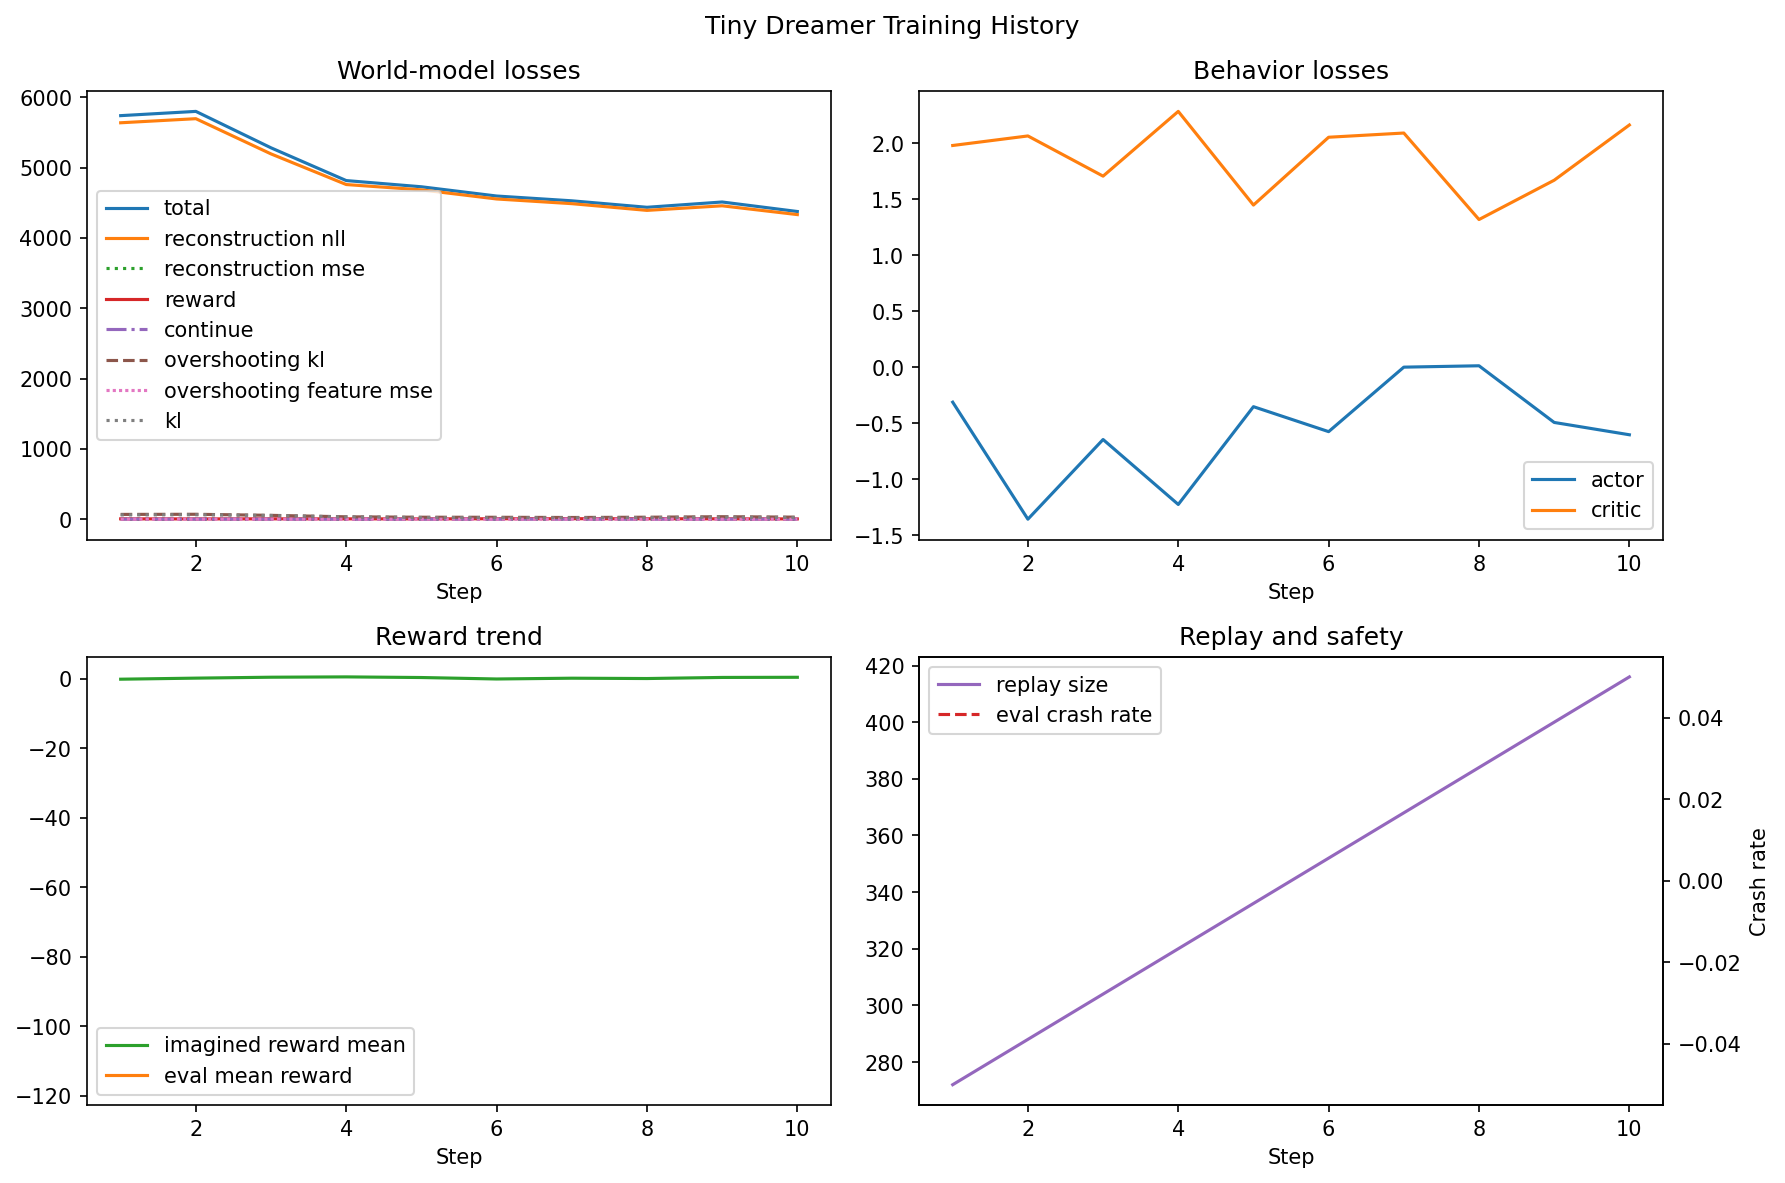

{'analysis_outputs': {'curves': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_curves.png',
  'summary': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_summary.json'},
 'analysis_summary': {'best_eval_mean_reward': -114.71901859426397,
  'best_eval_reward_step': 10,
  'best_imagined_reward_mean': 0.5974715352058411,
  'best_imagined_reward_step': 4,
  'best_world_model_step': 10,
  'best_world_model_total_loss': 4375.62158203125,
  'largest_replay_size': 416,
  'largest_replay_step': 10,
  'last_metrics': {'behavior/actor_loss': -0.6027070879936218,
   'behavior/critic_loss': 2.1632277965545654,
   'behavior/imagined_reward_mean': 0.48311519622802734,
   'behavior/imagined_value_mean': 0.7575069069862366,
   'evaluation/crash_rate': 0.0,
   'evaluation/episodes': 2.0,
   'evaluation/mean_reward': -114.71901859426397,
   'evaluation/mean_steps': 40.0,
   'p

In [8]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with metrics_csv_path.open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_outputs': {
        'curves': str(analysis_outputs['curves']),
        'summary': str(analysis_outputs['summary']),
    },
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'world_model/overshooting_pairs': latest_metrics_row.get('world_model/overshooting_pairs'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record a short GIF showing the trained policy driving in the real highway-env. The checkpoint from the run above is used to load the actor and world model, then the agent is rolled out for a few episodes.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=4 | reward=2.65 | CRASH | saved sanity_check_001_ep01.gif
[demo] episode 2/10 | steps=5 | reward=-7.40 | CRASH | saved sanity_check_001_ep02.gif
[demo] episode 3/10 | steps=40 | reward=-100.95 | OK | saved sanity_check_001_ep03.gif
[demo] episode 4/10 | steps=4 | reward=-4.37 | CRASH | saved sanity_check_001_ep04.gif
[demo] episode 5/10 | steps=40 | reward=-116.72 | OK | saved sanity_check_001_ep05.gif
[demo] episode 6/10 | steps=40 | reward=-101.10 | OK | saved sanity_check_001_ep06.gif
[demo] episode 7/10 | steps=40 | reward=-120.53 | OK | saved sanity_check_001_ep07.gif
[demo] episode 8/10 | steps=5 | reward=-4.26 | CRASH | saved sanity_check_001_ep08.gif
[demo] episode 9/10 | steps=40 | reward=-112.71 | OK | saved sanity_check_001_ep09.gif
[demo] episode 10/10 | steps=4 | reward=-5.19 | CRASH | saved sanity_check_001_ep10.gif
[demo] done | avg_reward=-57.06 | summary=sanity_check_00

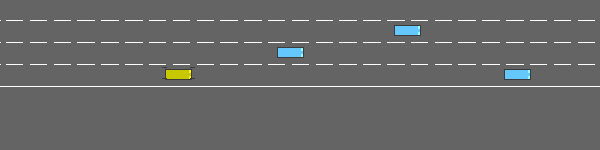


sanity_check_001_ep02.gif


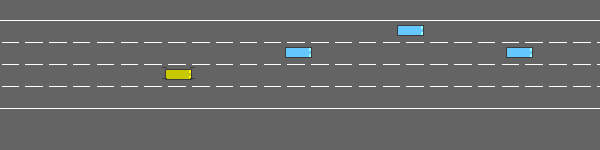


sanity_check_001_ep03.gif


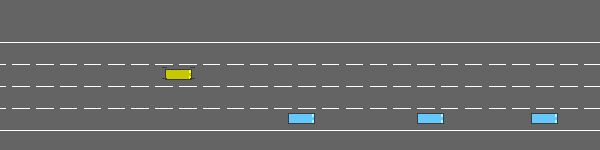


sanity_check_001_ep04.gif


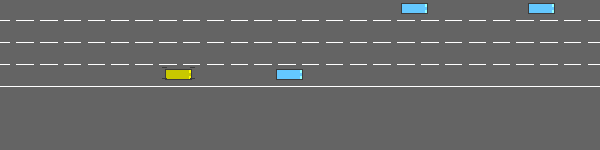


sanity_check_001_ep05.gif


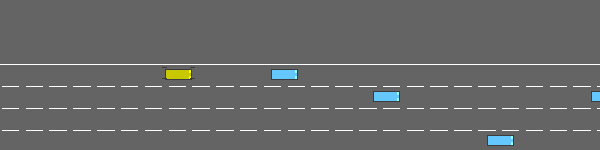


sanity_check_001_ep06.gif


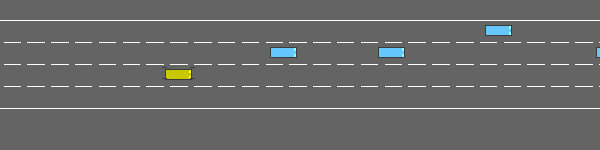


sanity_check_001_ep07.gif


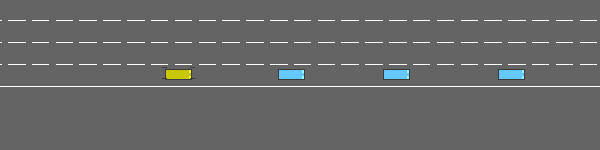


sanity_check_001_ep08.gif


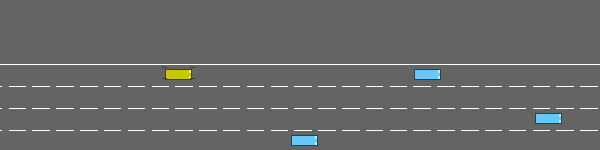


sanity_check_001_ep09.gif


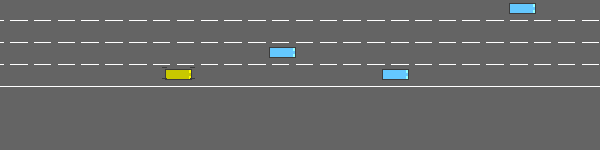


sanity_check_001_ep10.gif


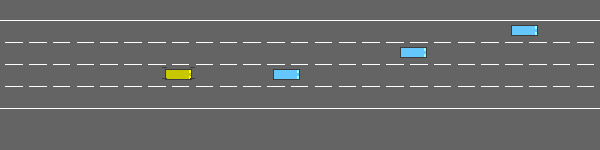

In [9]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=40,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))